In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
results_path = "../results"
plots_path = "../../../../../new_plots/structured_scenarios"
ppm_res = pd.read_csv(f"{results_path}/planner_designed_structs.csv")
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
figsize = (6, 4)

In [13]:
indices = ppm_res[ppm_res['heuristic'] == 'MIXED_G'].index
ppm_res.loc[indices, 'heuristic'] = 'MULTI_BOUND'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY', 'heuristic'] = 'ACP'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY_ONCE', 'heuristic'] = 'ACP_ONCE'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY_ONCE_DISCOUNT', 'heuristic'] = 'ACP_D'
ppm_res.loc[ppm_res['problem'] == 'club_house', 'problem'] = 'house'

h_order = ['LAZY', 'DILIGENT', 'MULTI_BOUND', 'ACP', 'ACP_ONCE', 'ACP_D']
ppm_res['heuristic'] = pd.Categorical(ppm_res['heuristic'], categories=h_order, ordered=True)

p_order = ['box', 'triangle', 'circle', 'house']
ppm_res['problem'] = pd.Categorical(ppm_res['problem'], categories=p_order, ordered=True)
ppm_res = ppm_res.sort_values('heuristic')
ppm_res = ppm_res.sort_values('problem')
ppm_res = ppm_res[~ppm_res['problem'].isin(['triangle'])].copy()
ppm_res['problem'] = ppm_res['problem'].cat.remove_unused_categories()

ppm_res_mean_cost = ppm_res.groupby(['heuristic', 'problem'])['cost'].mean().reset_index()
ppm_res_mean_time = ppm_res.groupby(['heuristic', 'problem'])['time_taken'].mean().reset_index()
ppm_res_mean_states = ppm_res.groupby(['heuristic', 'problem'])['states_explored'].mean().reset_index()

ppm_res_filtered = ppm_res[~ppm_res['heuristic'].isin(['ACP', 'ACP_D'])].copy()
ppm_res_filtered['heuristic'] = ppm_res_filtered['heuristic'].cat.remove_unused_categories()
ppm_res_filtered_mean_time = ppm_res_filtered.groupby(['heuristic', 'problem'])['time_taken'].mean().reset_index()
ppm_res_filtered_mean_states = ppm_res_filtered.groupby(['heuristic', 'problem'])['states_explored'].mean().reset_index()

ppm_res_mean_cost_ant = ppm_res_mean_cost[ppm_res_mean_cost['heuristic'].isin(['ACP',
                                                                               'ACP_ONCE',
                                                                               'ACP_D'])].copy()
ppm_res_mean_cost_non_ant = ppm_res_mean_cost[~ppm_res_mean_cost['heuristic'].isin(['ACP',
                                                                                    'ACP_D'])].copy()

ppm_res_mean_cost_ant['heuristic'] = ppm_res_mean_cost_ant['heuristic'].cat.remove_unused_categories()
ppm_res_mean_cost_non_ant['heuristic'] = ppm_res_mean_cost_non_ant['heuristic'].cat.remove_unused_categories()

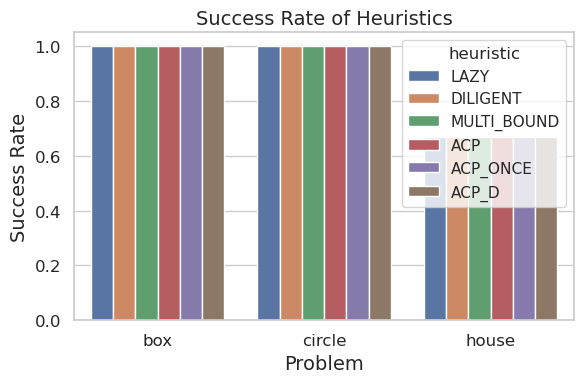

In [18]:
ppm_res_mean_cost['success_rate'] = ppm_res.groupby(['heuristic', 'problem'])['cost'].apply(lambda x: x.notna().mean()).values
fig, ax = plt.subplots(figsize=figsize)
sns.barplot(data=ppm_res_mean_cost, x='problem', y='success_rate', hue='heuristic', ax=ax)
ax.set_xlabel("Problem")
ax.set_ylabel("Success Rate")
ax.set_title("Success Rate of Heuristics")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
# plt.savefig(f"{plots_path}/structured_success_rate.pdf", dpi=300, bbox_inches='tight')
plt.show()

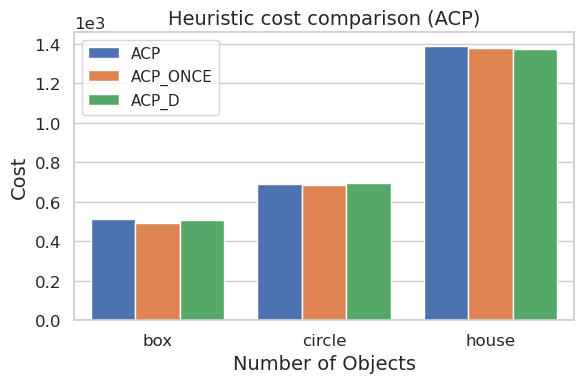

In [4]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_mean_cost_ant, x="problem", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Heuristic cost comparison (ACP)")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f"{plots_path}/structured_acp_costs.pdf", dpi=300, bbox_inches='tight')
plt.show()

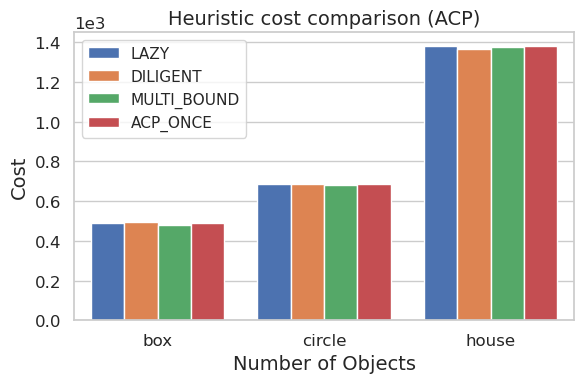

In [5]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_mean_cost_non_ant, x="problem", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Heuristic cost comparison (ACP)")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f"{plots_path}/structured_all_costs.pdf", dpi=300, bbox_inches='tight')
plt.show()

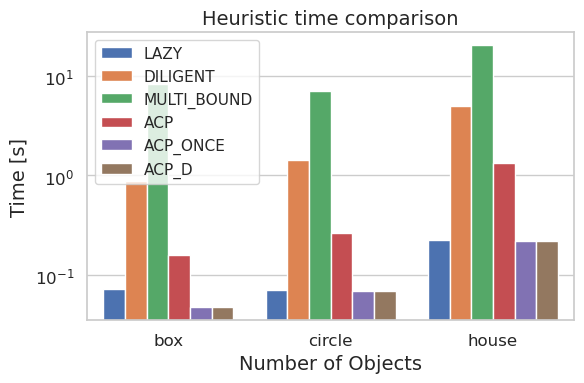

In [6]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_mean_time, x="problem", y="time_taken", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Time [s]")
ax.set_title("Heuristic time comparison")
ax.set_yscale('log')
ax.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.tight_layout()
plt.savefig(f"{plots_path}/structured_times.pdf", dpi=300, bbox_inches='tight')
plt.show()

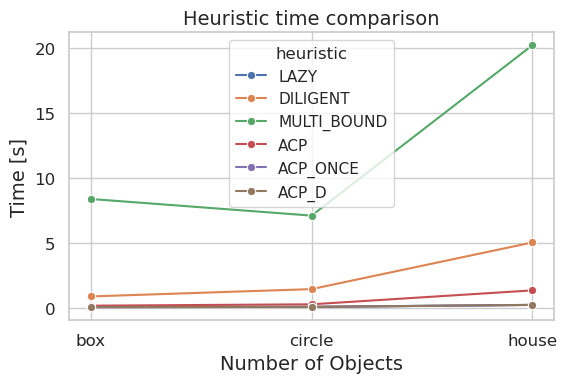

In [7]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.lineplot(data=ppm_res_mean_time, x="problem", y="time_taken", hue="heuristic", ax=ax, marker='o')
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Time [s]")
ax.set_title("Heuristic time comparison")
# ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f"{plots_path}/structured_times_line.pdf", dpi=300, bbox_inches='tight')
plt.show()

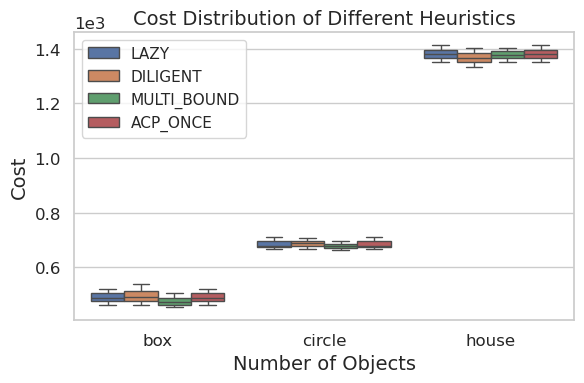

In [8]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.boxplot(data=ppm_res_filtered, x="problem", y="cost", hue="heuristic", ax=ax)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_title("Cost Distribution of Different Heuristics")
plt.tight_layout()
plt.legend(loc='upper left')
plt.savefig(f"{plots_path}/structured_cost_distibution.pdf", dpi=300, bbox_inches='tight')
plt.show()

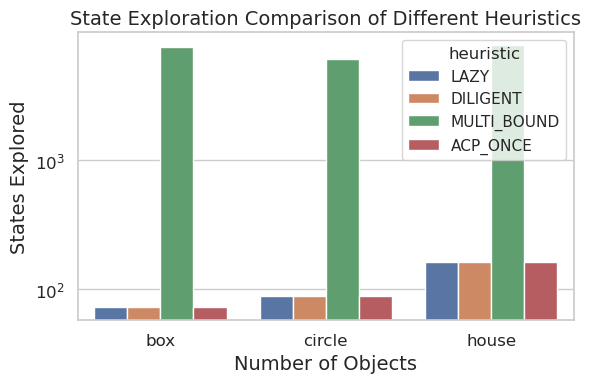

In [9]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res_filtered_mean_states, x="problem", y="states_explored", hue="heuristic", ax=ax)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("States Explored")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_yscale('log')
ax.set_title("State Exploration Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

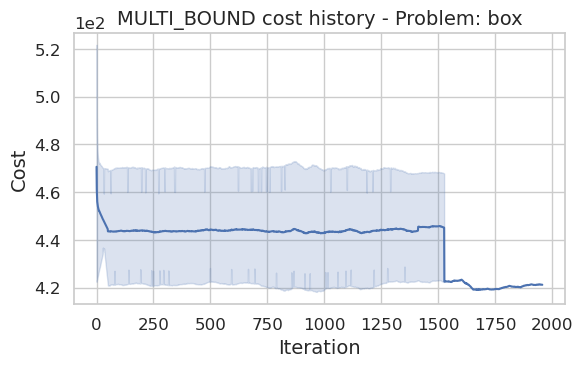

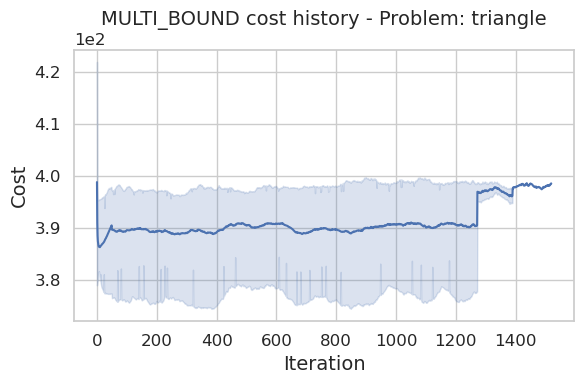

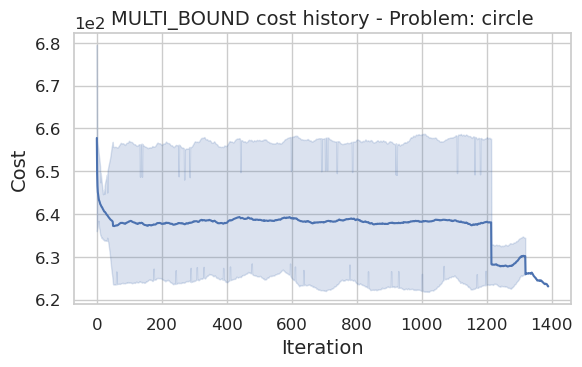

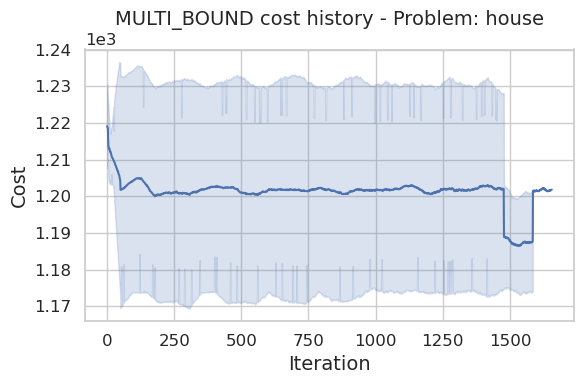

In [10]:
mb_cost_hist_df = pd.read_csv(f"{results_path}/planner_mb_planner_designed_structs_costs.csv")
problems = mb_cost_hist_df['problem'].unique()

window_size = 50
for problem in problems:
    subset = mb_cost_hist_df[(mb_cost_hist_df['problem'] == problem)]
    if subset.empty:
        continue

    subset['smoothed_cost'] = subset['cost'].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).mean()
    )

    plt.figure(figsize=figsize)
    sns.lineplot(data=subset, x="iter", y="smoothed_cost")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.title(f"MULTI_BOUND cost history - Problem: {problem}")
    plt.tight_layout()
    plt.savefig(f"{plots_path}/mb_costs/mb_cost_history_{problem}_dist.pdf",
                bbox_inches='tight', dpi=300)
    plt.show()

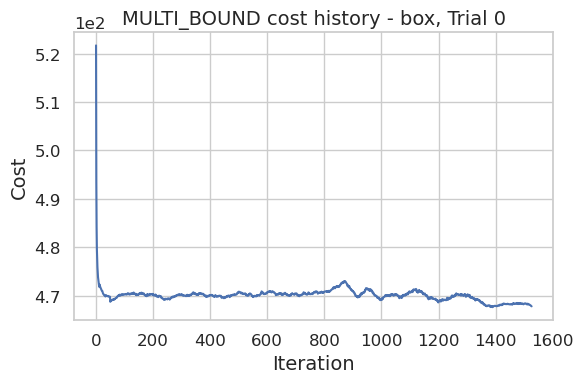

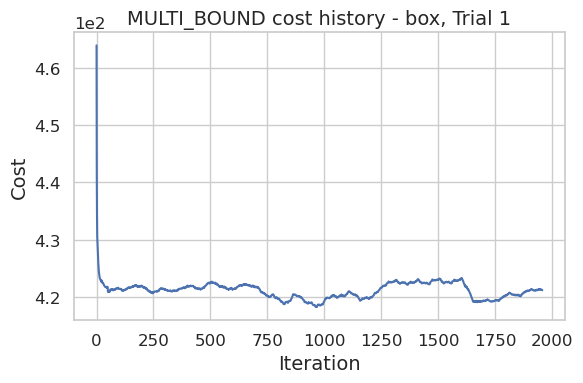

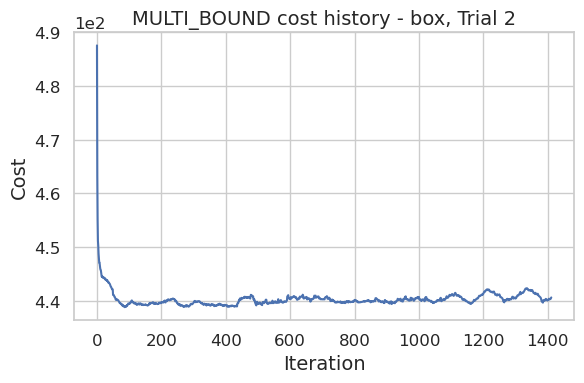

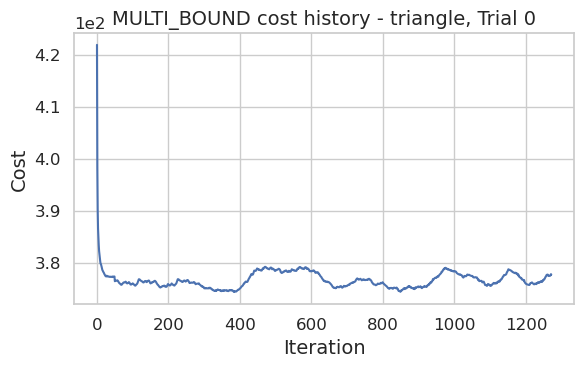

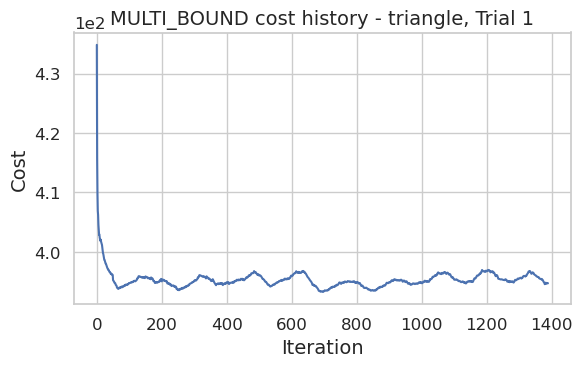

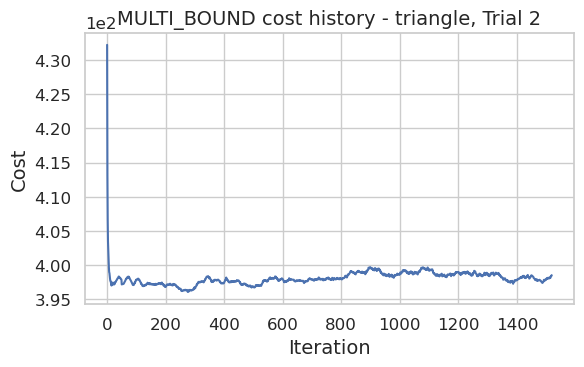

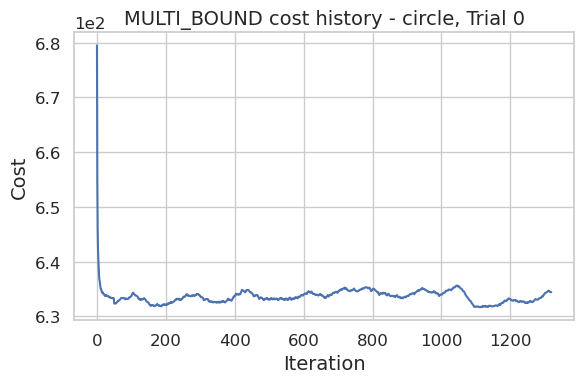

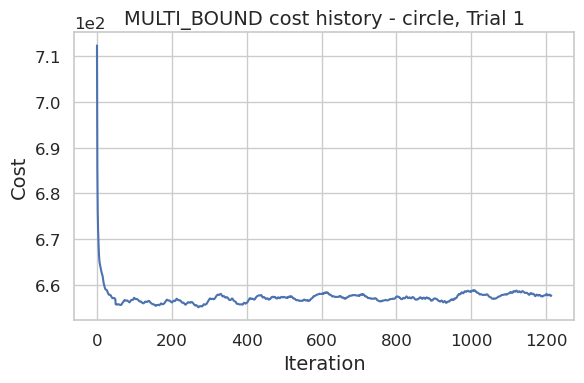

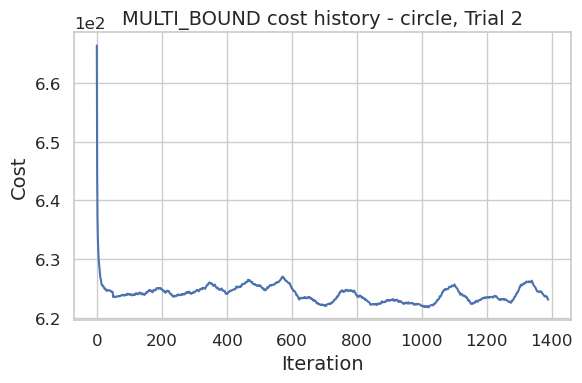

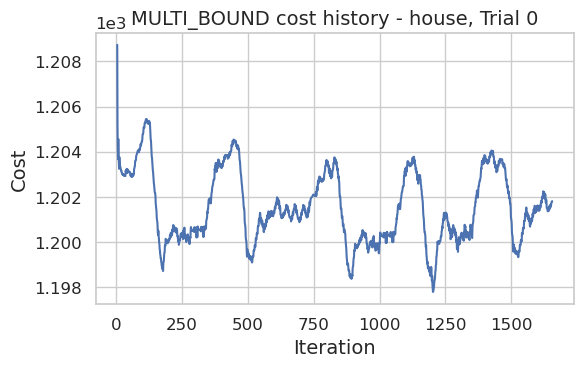

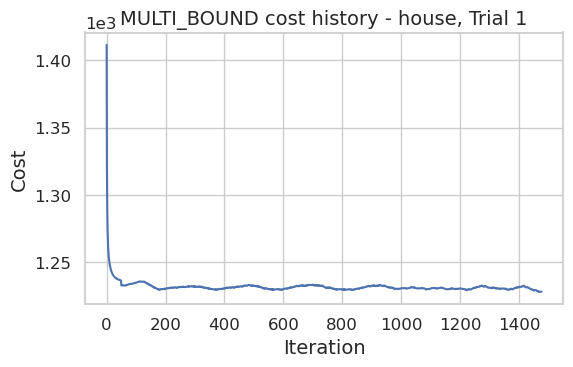

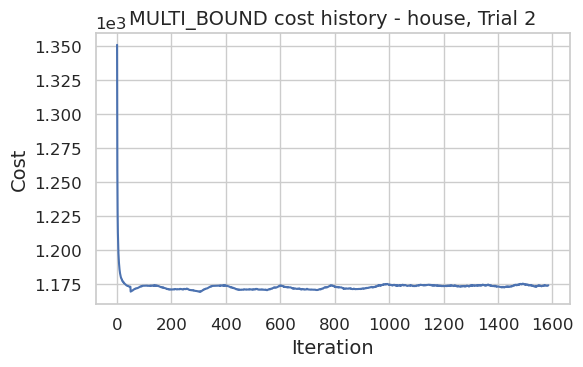

In [11]:
problems = mb_cost_hist_df['problem'].unique()
trials = mb_cost_hist_df['trial_num'].unique()
trials.sort()

window_size = 50
for problem in problems:
    for trial in trials:
        subset = mb_cost_hist_df[(mb_cost_hist_df['problem'] == problem) & (mb_cost_hist_df['trial_num'] == trial)]
        if subset.empty:
            continue

        subset['smoothed_cost'] = subset['cost'].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean()
        )

        plt.figure(figsize=figsize)
        sns.lineplot(data=subset, x="iter", y="smoothed_cost")
        plt.xlabel("Iteration")
        plt.ylabel("Cost")
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        plt.title(f"MULTI_BOUND cost history - {problem}, Trial {trial}")
        plt.tight_layout()
        plt.savefig(f"{plots_path}/mb_costs/mb_cost_history_{problem}_trial_{trial}.pdf",
                    bbox_inches='tight', dpi=300)
        plt.show()